### data structure
```
MEA/
└── 1/
    ├── rns_20250414_29679-1.raw.h5         # raw MaxWell recording
    ├── lfp/
    │   └── recording.zarr/                 # band-passed + downsampled MaxWell recording (not used)
    ├── spike/
    │   ├── mx_output_refined/
    │   │   └── firings.npz                 # MaxWell on-chip threshold detector (not used)
    │   ├── sorter_output/
    │   │   └── firings.npz                 # MountainSort5 output
    │   ├── sorter_output_refined/
    │   │   └── firings.npz                 # curated MountainSort5 output
    │   ├── sorting_analyzer.zarr/          # templates, unit positions
    │   ├── data_refined.npy                # per-spike table behind spike_map.png
    │   ├── data_refined_mx.npy             # same columns for the on-chip detector
    │   ├── spike_map.png                   # units X array figure
    │   ├── spikeinterface_log.json         # sorter version and run time
    │   ├── spikeinterface_params.json      # sorter parameters
    │   └── spikeinterface_recording.json   # metadata
    ├── probe_map.png                       # electrode layout with channel numbers
    └── file_list.npy                       # original path? (not used)
```

### probe_map.png

![](img/probe_map.png)  

https://pmc.ncbi.nlm.nih.gov/articles/PMC8900719/

"An almost arbitrary combination of up to 1,024 electrodes and be recorded from simultaneously" (881 green dots)

### spike_map.png

![](img/spike_map.png)

In [1]:
import os
import hashlib
import h5py
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import spikeinterface.full as si
from pathlib import Path
from scipy.stats import false_discovery_control

/Users/bryanzheng/.venvs/glioma-mea/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
h5py.h5pl.prepend(str(Path.home() / "hdf5_plugin_path_maxwell").encode())
os.environ["HDF5_PLUGIN_PATH"] = str(Path.home() / "hdf5_plugin_path_maxwell")

In [3]:
# paths
DATA_DIR = Path("/Users/bryanzheng/Library/CloudStorage/GoogleDrive-bzheng112@gmail.com/My Drive/data/MEA/1")
SORTING_NPZ = DATA_DIR / "spike" / "sorter_output_refined" / "firings.npz"
ANALYZER_DIR = DATA_DIR / "spike" / "sorting_analyzer.zarr"
RAW_H5 = DATA_DIR / "rns_20250414_29679-1.raw.h5"

In [4]:
rec = si.read_maxwell(RAW_H5)
fs = rec.sampling_frequency
n_samples = rec.get_num_samples()
duration = n_samples / fs
n_channels = rec.get_num_channels()

In [5]:
print("length (number of samples) = {:.0f}".format(n_samples))
print("sampling frequency = {:.0f} Hz".format(fs))
print("duration = {:.0f}".format(duration))
print("number of channels = {:.0f}".format(n_channels))

length (number of samples) = 6001800
sampling frequency = 20000 Hz
duration = 300
number of channels = 881


In [6]:
step = 100 # downsampling
channel = "81"
t_start, t_end = 33.0, 35.0

In [7]:
z = rec.get_traces(start_frame=int(t_start*fs), 
                   end_frame=int(t_end*fs),
                   channel_ids=[channel],
                   return_scaled=True)[::step,0]
z = z - np.median(z) # remove baseline
t = t_start + np.arange(z.size) * step / fs

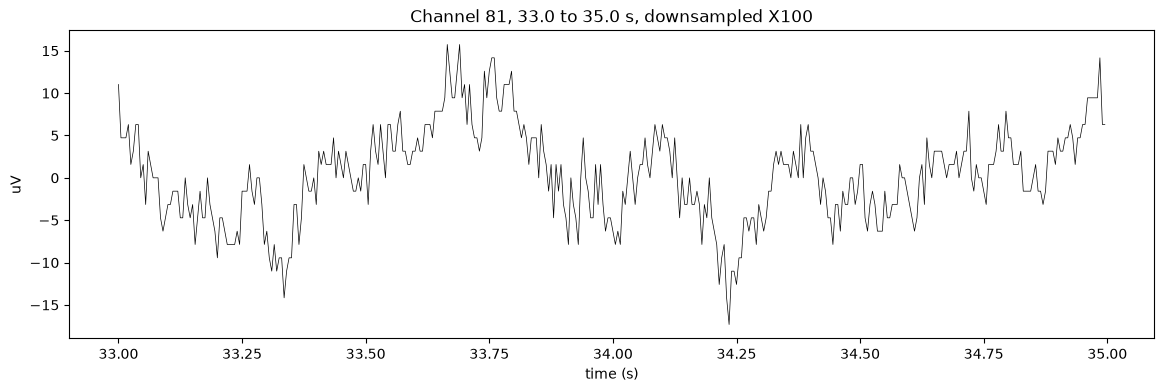

In [8]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(t, z, color="k", lw=0.5)
ax.set(xlabel="time (s)", ylabel="uV", title=f"Channel {channel}, {t_start} to {t_end} s, downsampled X{step}")
plt.show()

### spike sorting

MountainSort:  
https://www.sciencedirect.com/science/article/pii/S0896627317307456  
https://github.com/flatironinstitute/mountainlab-js  
https://github.com/flatironinstitute/mountainsort5  

In [9]:
detect_sign = -1 # default

In [10]:
SORT_DIR = Path.home() / "Downloads" / f"ms5"
firings = SORT_DIR / "sorter_output" / "firings.npz"

In [11]:
rec_in = si.center(si.scale_to_uV(si.unsigned_to_signed(rec)), mode="median")

In [12]:
params = dict(scheme="2", detect_sign=detect_sign, detect_threshold=5.5,
              snippet_T2=40, snippet_mask_radius=50,
              scheme2_training_duration_sec=60,
              filter=True, whiten=True, n_jobs=1)   

In [13]:
#https://spikeinterface.readthedocs.io/en/stable/modules/sorters.html
if firings.exists():
    sorting_new = si.read_npz_sorting(firings)      # an analysed sort is loaded, never redone
else:
    sorting_new = si.run_sorter("mountainsort5", 
                                rec_in,
                                folder=SORT_DIR,
                                verbose=False, 
                                **params)

In [14]:
print(sorting_new)
print("units:", sorting_new.get_num_units(), "| spikes:", sorting_new.to_spike_vector().size, "| md5:", hashlib.md5(firings.read_bytes()).hexdigest()[:8])

NpzSortingExtractor: 40 units - 1 segments - 20.0kHz
  file_path: /Users/bryanzheng/Downloads/ms5/sorter_output/firings.npz
units: 40 | spikes: 7167 | md5: ec6495d8


In [15]:
analyzer = si.create_sorting_analyzer(sorting_new, rec_in, sparse=True, n_jobs=1)
analyzer.compute(["random_spikes", "waveforms", "templates", "unit_locations"], n_jobs=1)
xy = analyzer.get_extension("unit_locations").get_data()[:,:2]

compute_waveforms (no parallelization): 100%|█████████████████████████████| 301/301 [00:47<00:00,  6.38it/s]


In [16]:
print(xy.shape, "| x range", xy[:, 0].min().round(), xy[:, 0].max().round(), "| y range", xy[:, 1].min().round(), xy[:, 1].max().round())

(40, 2) | x range 12.0 1229.0 | y range 127.0 1898.0


In [17]:
analyzer.compute("template_similarity")                      # cosine similarity of the average waveforms, per pair of units
sim = analyzer.get_extension("template_similarity").get_data()
sim_ids = list(analyzer.unit_ids)
def template_sim(a, b):
    """cosine similarity of the templates of units a and b: ~1 same waveform, ~0 unrelated"""
    return float(sim[sim_ids.index(a), sim_ids.index(b)])
print("templates available for", len(sim_ids), "units")

templates available for 40 units


In [18]:
units = list(sorting_new.unit_ids)
spike_times={u: sorting_new.get_unit_spike_train(u) / fs for u in units}
rate = np.array([len(spike_times[u]) / duration for u in units])
xy_unit = {u: xy[k] for k, u in enumerate(sorting_new.unit_ids)}   # position by unit id
xy_units = np.array([xy_unit[u] for u in units])                    # positions in the order of `units`

In [19]:
elec = rec.get_channel_locations()

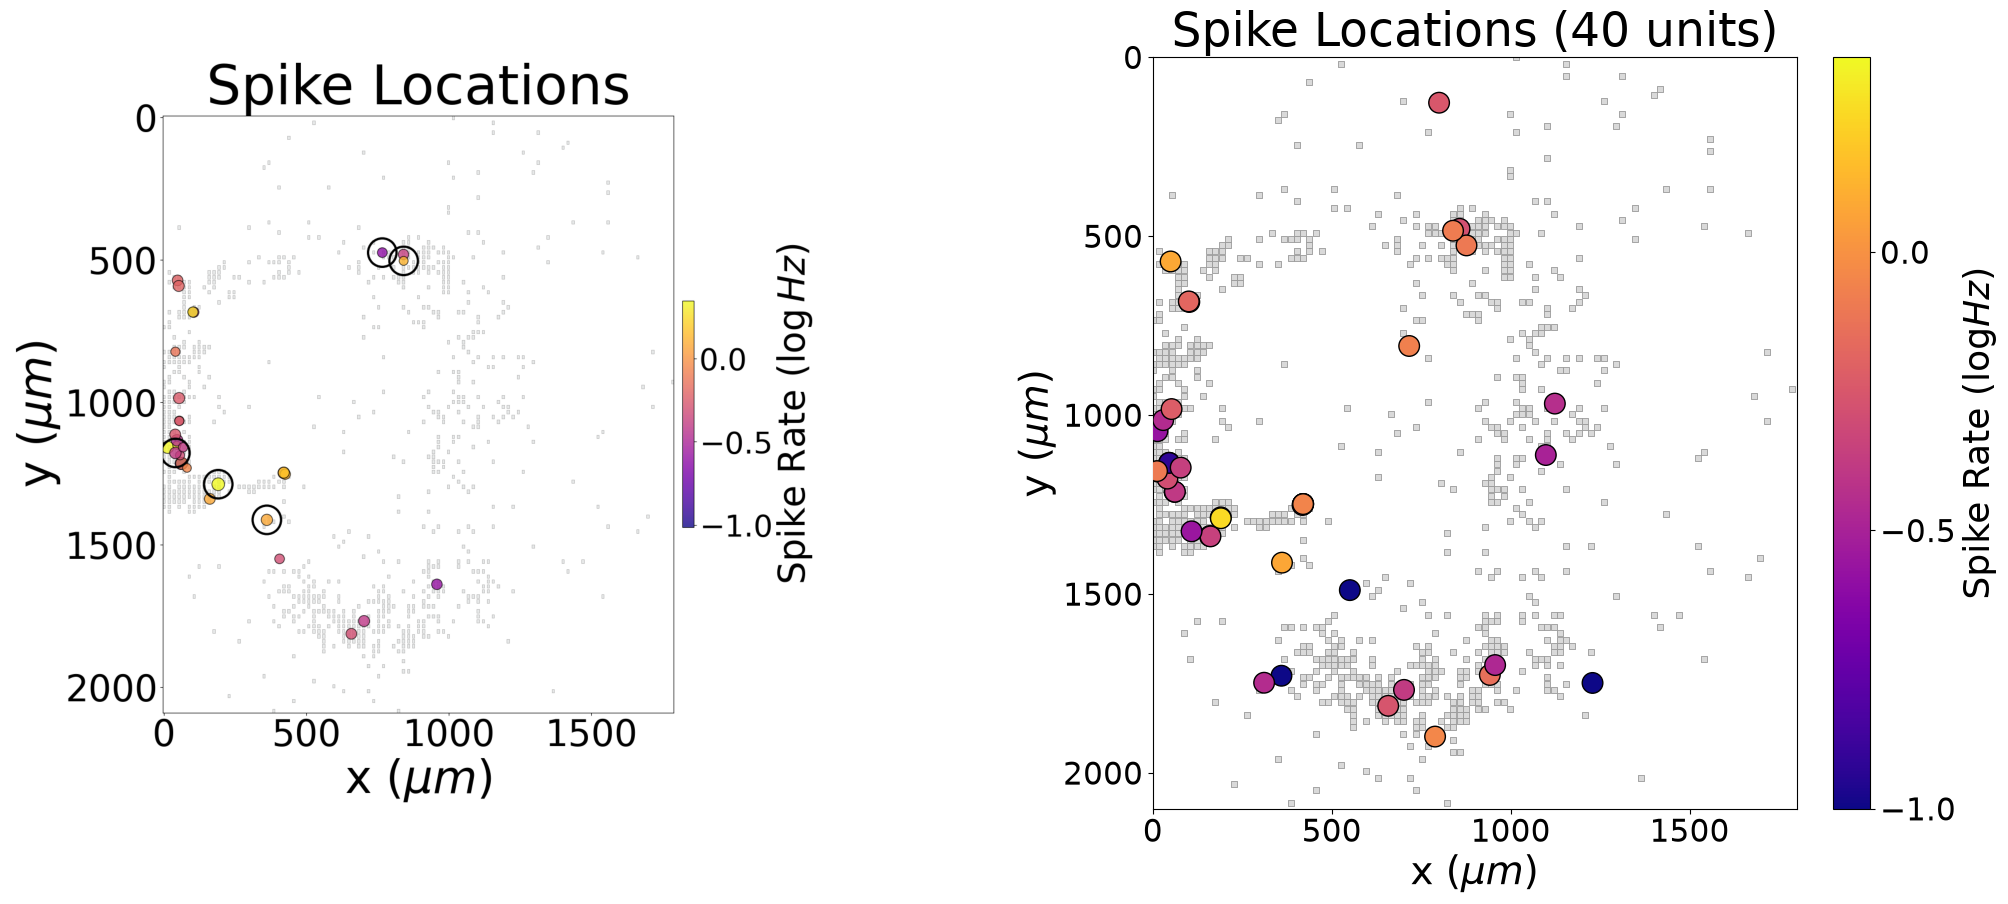

In [20]:
plt.rcParams.update({"font.size": 22})
img = plt.imread(DATA_DIR / "spike" / "spike_map.png")
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(21, 9.5))

ax0.imshow(img)
ax0.axis("off")

ax1.scatter(elec[:, 0], elec[:, 1], s=18, marker="s", facecolor="0.85", edgecolor="0.6", linewidth=0.6)
sc = ax1.scatter(xy_units[:, 0], xy_units[:, 1], c=np.log10(rate), cmap="plasma", s=220, edgecolor="k", linewidth=1.0,
                 vmin=-1.0, vmax=0.35, zorder=3)
cb = fig.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
cb.set_label(r"Spike Rate (log$Hz$)", fontsize=26)
cb.set_ticks([-1.0, -0.5, 0.0])
ax1.set(xlim=(0, 1800), ylim=(2100, 0), aspect="equal")
ax1.set_xticks([0, 500, 1000, 1500])
ax1.set_yticks([0, 500, 1000, 1500, 2000])
ax1.set_xlabel(r"x ($\mu m$)", fontsize=28)
ax1.set_ylabel(r"y ($\mu m$)", fontsize=28)
ax1.set_title(f"Spike Locations ({len(units)} units)", fontsize=34)
fig.tight_layout()
plt.show()

### prelim figure

![](img/network.png)

1. raster plots - cortex-ganglionic eminence (Cx+GE) control (iCtrl) vs mutated (Mut) organoid
2. 31 x 31 functional connectivity matrix
3. constructed network with summary statistics + 3/4-node motif analysis
4. stimulation panel (100 ms train at 200 Hz; response amplitude and PD).

### raster

In [21]:
x = np.concatenate([spike_times[u] for u in units])
y = np.concatenate([np.full(len(spike_times[u]), k + 1) for k, u in enumerate(units)])

points: 7167


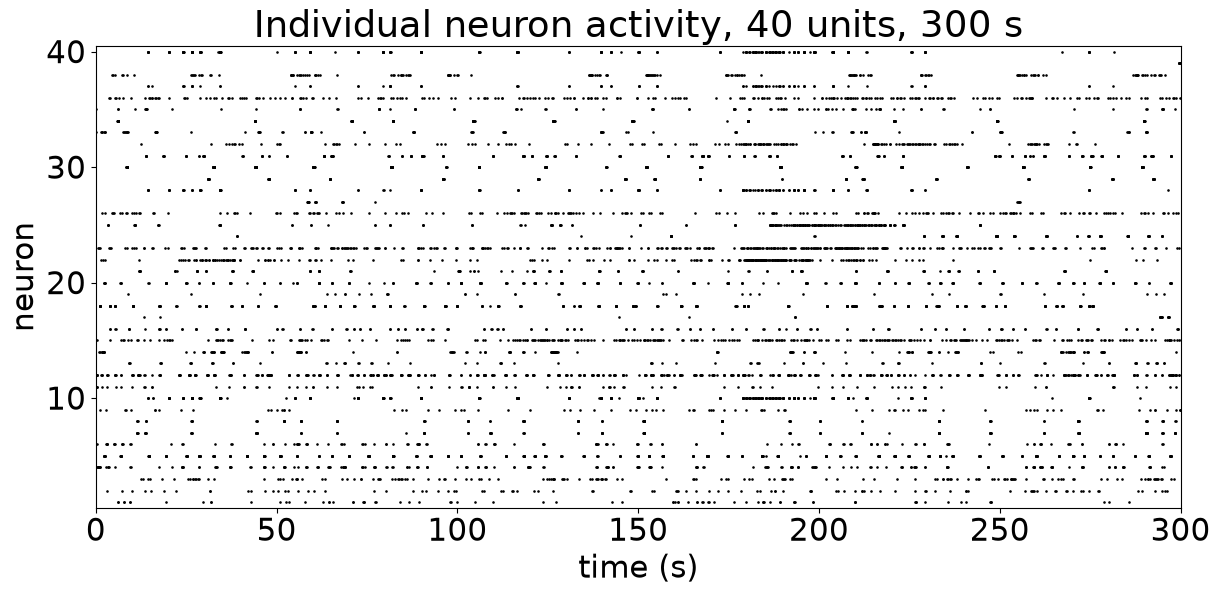

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(x, y, s=3, c="k", marker=".")
ax.set(xlim=(0, duration), ylim=(0.5, len(units) + 0.5), xlabel="time (s)", ylabel="neuron", title=f"Individual neuron activity, {len(units)} units, {duration:.0f} s")
print("points:", x.size)
plt.show()

### functional connectivity

https://www.cell.com/cell-reports-methods/fulltext/S2667-2375(24)00291-1

In [23]:
def fraction_within(ta, tb, w):
    """ fraction of spikes in ta with a spike in tb within +/- w seconds (both sorted)"""
    j = np.clip(np.searchsorted(tb, ta), 1, len(tb)-1)
    d = np.minimum(np.abs(tb[j] - ta), np.abs(tb[j -1] - ta))
    return (d <= w).mean()

In [24]:
def crosscorrelogram(ta, tb, max_lag=0.05, bin_s=0.001):
    """counts of tb spikes at each lag relative to every ta spike"""
    lags = np.concatenate([tb[(tb > t - max_lag) & (tb < t + max_lag)] - t for t in ta])
    bins = np.arange(-max_lag, max_lag + bin_s, bin_s)
    return np.histogram(lags, bins)[0], (bins[:-1] + bins[1:]) / 2 * 1000

In [25]:
def coverage(t, w, duration):
    """fraction of the recording within +/- w seconds of a spike in t (sorted): the chance term of STTC"""
    lo, hi = np.clip(t - w, 0, duration), np.clip(t + w, 0, duration)
    start = np.maximum(lo[1:], hi[:-1])                    # a window overlapping the previous one starts where that one ended
    return (hi[0] - lo[0] + np.maximum(hi[1:] - start, 0).sum()) / duration

In [26]:
def sttc(ta, tb, w, duration):
    """spike time tiling coefficient (Cutts & Eglen 2014): mean over both directions of (fraction within - chance) / (1 - fraction within * chance)"""
    pa, pb = fraction_within(ta, tb, w), fraction_within(tb, ta, w)
    ca, cb = coverage(ta, w, duration), coverage(tb, w, duration)
    return 0.5 * ((pa - cb) / (1 - pa * cb) + (pb - ca) / (1 - pb * ca))

In [27]:
rows = []
for i in range(len(units)):
    for j in range(i + 1, len(units)):
        a, b = units[i], units[j]
        small, big = sorted((spike_times[a], spike_times[b]), key=len)
        f2 = fraction_within(small, big, 0.002)
        if f2 > 0.1:
            rows.append(dict(unit_a=a, unit_b=b, n_small=len(small),
                             f_05ms=round(fraction_within(small, big, 0.0005), 3),
                             f_2ms=round(f2, 3),
                             dist_um=round(np.hypot(*(xy_unit[a] - xy_unit[b]))),
                             template_sim=round(template_sim(a, b), 2)))
suspects = pd.DataFrame(rows, columns=["unit_a", "unit_b", "n_small", "f_05ms", "f_2ms", "dist_um", "template_sim"]).sort_values("f_2ms", ascending=False).reset_index(drop=True)   # columns named so an empty table still has them

In [28]:
suspects

,unit_a,unit_b,n_small,f_05ms,f_2ms,dist_um,template_sim
0,11,29,159,0.415,0.836,0,0.45
1,11,41,264,0.034,0.807,0,0.49
2,11,38,94,0.691,0.691,3,0.77
3,38,41,94,0.000,0.670,3,0.48
4,29,41,159,0.579,0.579,0,0.89
5,29,38,94,0.000,0.266,3,0.44
6,26,36,102,0.147,0.147,31,0.47
7,6,21,241,0.133,0.133,1,0.89
8,14,20,36,0.111,0.111,0,0.89


In [29]:
# second criterion: a pair whose cross-correlogram has >= 30 counts in the 6-30 ms flanks but < 25% of the
# expected counts in the 1.5-6 ms band shares a refractory period, ie is one neuron split in two (burst split)
rows = []
for i in range(len(units)):
    for j in range(i + 1, len(units)):
        a, b = units[i], units[j]
        h, lag = crosscorrelogram(spike_times[a], spike_times[b])
        gap = h[(np.abs(lag) > 1.5) & (np.abs(lag) <= 6)].sum()
        flank = h[(np.abs(lag) > 6) & (np.abs(lag) <= 30)].sum()
        expected = flank * 9 / 48                       # 9 ms of gap bins, 48 ms of flank bins
        if flank >= 30 and gap < 0.25 * expected:
            rows.append(dict(unit_a=a, unit_b=b, gap=gap, flank=flank, expected_gap=round(expected, 1),
                             dist_um=round(np.hypot(*(xy_unit[a] - xy_unit[b]))),
                             template_sim=round(template_sim(a, b), 2)))
refractory_splits = pd.DataFrame(rows, columns=["unit_a", "unit_b", "gap", "flank", "expected_gap", "dist_um", "template_sim"])

In [30]:
refractory_splits

,unit_a,unit_b,gap,flank,expected_gap,dist_um,template_sim
0,6,21,0,277,51.9,1,0.89
1,8,9,0,184,34.5,1,0.68
2,11,29,0,409,76.7,0,0.45
3,11,38,0,235,44.1,3,0.77
4,11,41,0,686,128.6,0,0.49
5,29,38,0,120,22.5,3,0.44
6,29,41,0,324,60.8,0,0.89
7,38,41,0,190,35.6,3,0.48


In [31]:
# third criterion: a sub-millisecond fixed-lag coincidence. two units are one neuron if >= 3 of the smaller unit's spikes fall within
# 0.25 ms of the other's, that is > 20x what a circular shift gives, and the 0.25-5 ms band holds fewer coincidences than the 0.25 ms core
# (a synapse cannot act within 0.25 ms, and a synaptic peak sits at 0.5-5 ms; this catches the soma + axon splits the waveform rule misses)
rng_dup = np.random.default_rng(1)
rows = []
for i in range(len(units)):
    for j in range(i + 1, len(units)):
        a, b = units[i], units[j]
        small, big = sorted((spike_times[a], spike_times[b]), key=len)
        n_core = round(fraction_within(small, big, 0.00025) * len(small))
        n_band = round(fraction_within(small, big, 0.005) * len(small)) - n_core
        chance = np.mean([fraction_within(np.sort((small + rng_dup.uniform(1, duration - 1)) % duration), big, 0.00025) for _ in range(20)]) * len(small)
        if n_core >= 3 and n_core > 20 * chance and n_band < n_core:
            rows.append(dict(unit_a=a, unit_b=b, n_small=len(small), n_within_025ms=n_core, chance_025ms=round(chance, 2), n_025_5ms=n_band,
                             dist_um=round(np.hypot(*(xy_unit[a] - xy_unit[b]))), template_sim=round(template_sim(a, b), 2)))
subms_pairs = pd.DataFrame(rows, columns=["unit_a", "unit_b", "n_small", "n_within_025ms", "chance_025ms", "n_025_5ms", "dist_um", "template_sim"])

In [32]:
subms_pairs

,unit_a,unit_b,n_small,n_within_025ms,chance_025ms,n_025_5ms,dist_um,template_sim
0,6,21,241,32,0.15,0,1,0.89
1,8,9,122,3,0.00,0,1,0.68
2,11,38,94,65,0.00,0,3,0.77
3,12,13,95,7,0.05,0,2,0.88
4,14,20,36,4,0.00,0,0,0.89
5,16,27,199,4,0.10,0,2,0.50
6,26,36,102,14,0.05,1,31,0.47
7,29,41,159,92,0.05,0,0,0.89


In [33]:
thresh = 0.1      # coincidence rule: > 10% of the smaller unit's spikes within 2 ms of the other AND a shared waveform (template_sim > 0.5)
min_sim = 0.5     # refractory rule (refractory_splits) needs no waveform condition: the phase-offset re-detections have sim ~0.4
pairs = (suspects.loc[(suspects.f_2ms > thresh) & (suspects.template_sim > min_sim), ["unit_a", "unit_b"]].values.tolist()
         + refractory_splits[["unit_a", "unit_b"]].values.tolist()
         + subms_pairs[["unit_a", "unit_b"]].values.tolist())
groups = [sorted(g, key=lambda u: -len(spike_times[u])) for g in nx.connected_components(nx.Graph(pairs))]
duplicates = {g[0]: g[1:] for g in groups}

In [34]:
duplicates

{11: [41, 29, 38], 6: [21], 14: [20], 8: [9], 13: [12], 16: [27], 26: [36]}

In [35]:
for keep, absorbed in duplicates.items():
    t = np.sort(np.concatenate([spike_times[keep]] + [spike_times.pop(u) for u in absorbed]))
    spike_times[keep] = t[np.r_[True, np.diff(t) >= 0.001]]
units = sorted(spike_times)
rate = np.array([len(spike_times[u]) / duration for u in units])
xy_units = np.array([xy_unit[u] for u in units])

In [36]:
print(len(units), "units,", sum(len(t) for t in spike_times.values()), "spikes")

31 units, 6641 spikes


In [37]:
min_spikes = 30   # a unit enters the connectivity analysis only with >= 30 spikes (0.1 Hz over 300 s): fewer cannot support a null
units = [u for u in units if len(spike_times[u]) >= min_spikes]
print(len(units), "units with >=", min_spikes, "spikes")
w = 0.050   # tiling window +/- 50 ms (MEA-NAP setting for human organoids, Sit et al. 2024)
n = len(units)
iu = np.triu_indices(n, 1)
C = np.zeros((n, n))
for i, j in zip(*iu):
    C[i, j] = C[j, i] = sttc(spike_times[units[i]], spike_times[units[j]], w, duration)
k = np.argmax(C[iu])
print("STTC ({} ms): max {:.3f} ({} vs {}) | median {:.3f}".format(int(w * 1000), C[iu][k], units[iu[0][k]], units[iu[1][k]], np.median(C[iu])))

28 units with >= 30 spikes
STTC (50 ms): max 0.117 (23 vs 24) | median -0.001


In [38]:
def shift(t, rng, J=None):
    """whole train moved by ONE random offset and wrapped at the recording end, so every interspike interval (bursts included) is kept and only timing relative to the other units is destroyed.
    J=None: offset anywhere in the recording = circular shift (MEA-NAP, Sit et al. 2024). J in seconds: offset within +/- J = spike-train jitter that also keeps co-modulation slower than J in the null."""
    off = rng.uniform(1, duration - 1) if J is None else rng.uniform(-J, J)
    return np.sort((t + off) % duration)

In [39]:
rng = np.random.default_rng(0)
J = 1.0            # whole-train jitter within +/- 1 s (Colin's jitter null, interspike intervals kept); None = circular shift (the MEA-NAP null)
null_name = "circular shift" if J is None else f"+/- {J:g} s train jitter"
n_surr = 10_000    # p is a multiple of 1/(n_surr+1); BH over ~500 pairs at q=0.05 needs the smallest p near 1e-4
null = np.empty((n_surr, len(iu[0])))
for s in range(n_surr):
    ts = {u: shift(spike_times[u], rng, J) for u in units}
    null[s] = [sttc(ts[units[i]], ts[units[j]], w, duration) for i, j in zip(*iu)]
p = (1 + (null >= C[iu]).sum(0)) / (1 + n_surr)       # one-sided: tiled more than shifted; +1 so p is never 0 (Phipson & Smyth 2010)
z = (C[iu] - null.mean(0)) / null.std(0)                       # how many null SDs above chance each pair sits
sig_95 = C[iu] > np.percentile(null, 95, axis=0)                # MEA-NAP rule: per-pair 95th percentile of the circular-shift null, uncorrected
print(null_name + " null: {} surrogates | smallest possible p {:.1e} | pairs at that floor: {}".format(n_surr, 1 / (1 + n_surr), (p == 1 / (1 + n_surr)).sum()))
print("significant pairs: {} past the 95th percentile (~{:.0f} expected by chance) | pairs with z > 3: {} (~{:.1f} by chance)".format(sig_95.sum(), 0.05 * sig_95.size, (z > 3).sum(), 0.00135 * z.size))

+/- 1 s train jitter null: 10000 surrogates | smallest possible p 1.0e-04 | pairs at that floor: 0
significant pairs: 14 past the 95th percentile (~19 expected by chance) | pairs with z > 3: 0 (~0.5 by chance)


In [40]:
q = 0.05
p_adj = false_discovery_control(p, method="bh")
sig = p_adj <= q                                                 # confirmed layer: BH over all pairs, on the same surrogate p-values
print("BH q = {}: {} of the {} significant pairs survive correction | expected false among them: {:.1f}".format(q, sig.sum(), sig_95.sum(), q * sig.sum()))
pd.DataFrame([(units[iu[0][k]], units[iu[1][k]], round(C[iu][k], 3), round(z[k], 1), p[k], round(p_adj[k], 3), "BH" if sig[k] else "95th pct")
              for k in np.where(sig_95)[0]], columns=["unit_a", "unit_b", "sttc", "z", "p", "p_adj", "layer"]).sort_values("z", ascending=False).head(15)

BH q = 0.05: 0 of the 14 significant pairs survive correction | expected false among them: 0.0


,unit_a,unit_b,sttc,z,p,p_adj,layer
8,11,37,0.096,2.9,0.022498,0.956,95th pct
1,2,37,0.051,2.8,0.017898,0.956,95th pct
2,3,4,0.036,2.5,0.014199,0.956,95th pct
12,23,24,0.117,2.4,0.029097,0.956,95th pct
0,2,15,0.032,2.1,0.012799,0.956,95th pct
3,4,6,0.037,2.0,0.034897,0.956,95th pct
7,10,23,0.051,2.0,0.029397,0.956,95th pct
11,19,37,0.039,1.9,0.042896,0.956,95th pct
5,7,39,0.039,1.8,0.044396,0.956,95th pct
9,15,24,0.017,1.8,0.032497,0.956,95th pct


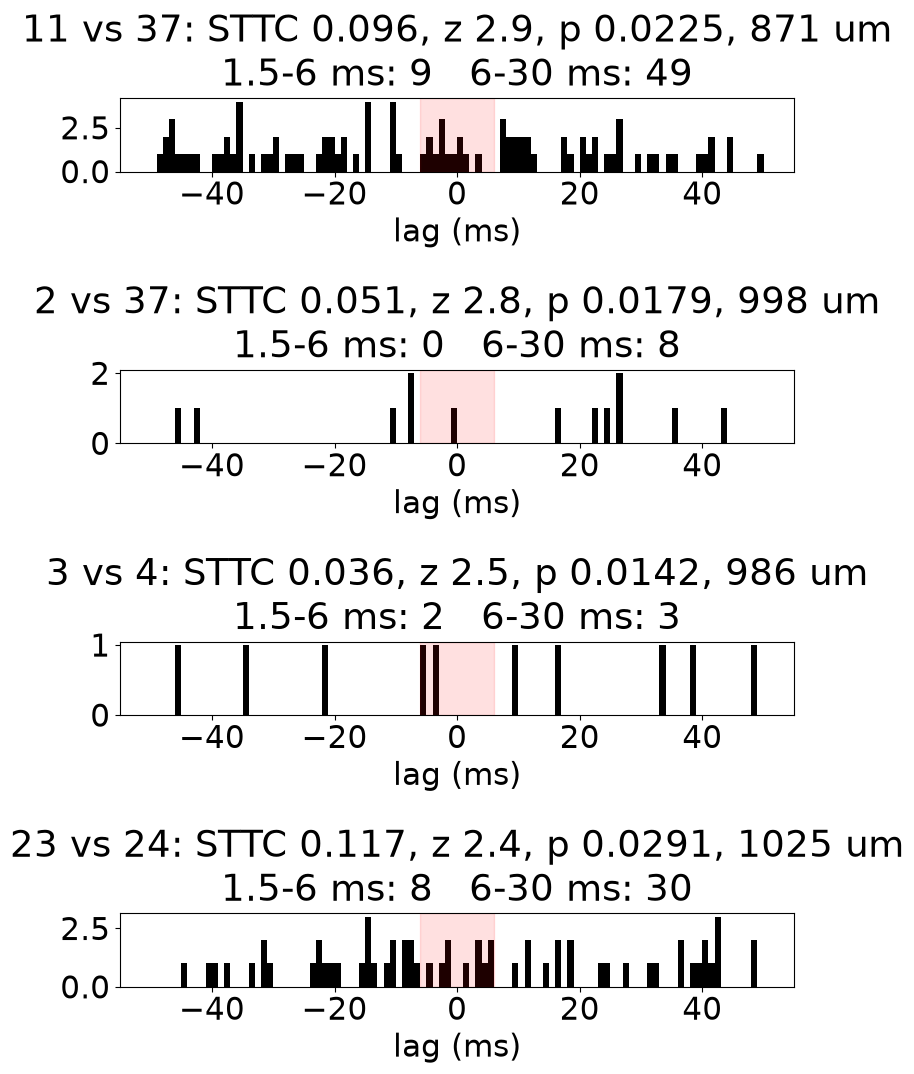

In [41]:
k_show = np.where(sig)[0] if sig.any() else np.argsort(z)[::-1][:4]      # BH-confirmed pairs, or the 4 highest z when none
sig_pairs = [(units[iu[0][k]], units[iu[1][k]]) for k in k_show]
fig, axs = plt.subplots(len(k_show), 1, figsize=(8, 2.8 * len(k_show)))
for ax, k in zip(np.atleast_1d(axs), k_show):
    a, b = units[iu[0][k]], units[iu[1][k]]
    h, lag_ms = crosscorrelogram(spike_times[a], spike_times[b])
    ax.bar(lag_ms, h, width=1, color="k")
    ax.axvspan(-6, 6, color="red", alpha=0.12)
    gap = h[(np.abs(lag_ms) > 1.5) & (np.abs(lag_ms) <= 6)].sum()
    flank = h[(np.abs(lag_ms) > 6) & (np.abs(lag_ms) <= 30)].sum()
    ax.set(title=f"{a} vs {b}: STTC {C[iu][k]:.3f}, z {z[k]:.1f}, p {p[k]:.4f}, {np.hypot(*(xy_unit[a] - xy_unit[b])):.0f} um\n1.5-6 ms: {gap}   6-30 ms: {flank}", xlabel="lag (ms)")
fig.tight_layout()
plt.show()

In [42]:
mask = np.tril(np.ones_like(C, dtype=bool))          # hide the lower triangle and the diagonal
C_half = np.ma.array(C, mask=mask)
Z = np.zeros_like(C); Z[iu] = z; Z = Z + Z.T                     # z-scores as a matrix
Z_half = np.ma.array(Z, mask=mask)

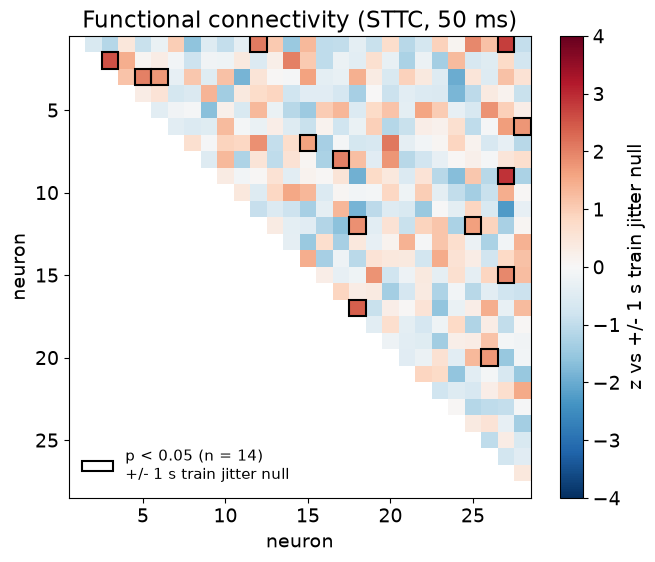

In [51]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(Z_half, cmap="RdBu_r", vmin=-4, vmax=4, extent=(0.5, n + 0.5, n + 0.5, 0.5))
for m, k in enumerate(np.where(sig_95)[0]):
    i, j = iu[0][k], iu[1][k]
    ax.add_patch(plt.Rectangle((j + 0.5, i + 0.5), 1, 1, fill=False, edgecolor="k", linewidth=1.5,
                               label=f"p < 0.05 (n = {sig_95.sum()})\n{null_name} null" if m == 0 else None))
fig.colorbar(im, ax=ax, label=f"z vs {null_name} null")
if sig_95.any(): ax.legend(loc="lower left", frameon=False, fontsize=11)
ax.set(xlabel="neuron", ylabel="neuron", title=f"Functional connectivity (STTC, {int(w * 1000)} ms)")
plt.show()

### networks

In [44]:
G = nx.Graph()
G.add_nodes_from(units)                                                              # nodes are unit ids
for k in np.where(sig_95)[0]:
    G.add_edge(units[iu[0][k]], units[iu[1][k]], weight=C[iu][k], z=z[k], confirmed=bool(sig[k]))   # edge weight is STTC
n_conf = sum(d["confirmed"] for _, _, d in G.edges(data=True))
print("nodes:", G.number_of_nodes(), "| edges (p < 0.05):", G.number_of_edges(), f"(~{0.05 * sig_95.size:.0f} expected by chance)",
      "| BH-confirmed:", n_conf, "| isolated nodes:", sum(1 for u in G if G.degree(u) == 0))

nodes: 28 | edges (p < 0.05): 14 (~19 expected by chance) | BH-confirmed: 0 | isolated nodes: 11


In [45]:
pos = {u: xy_unit[u] for u in units}
edge_colors = ["red" if G[u][v]["weight"] > 0 else "blue" for u, v in G.edges]
edge_widths = 1.5

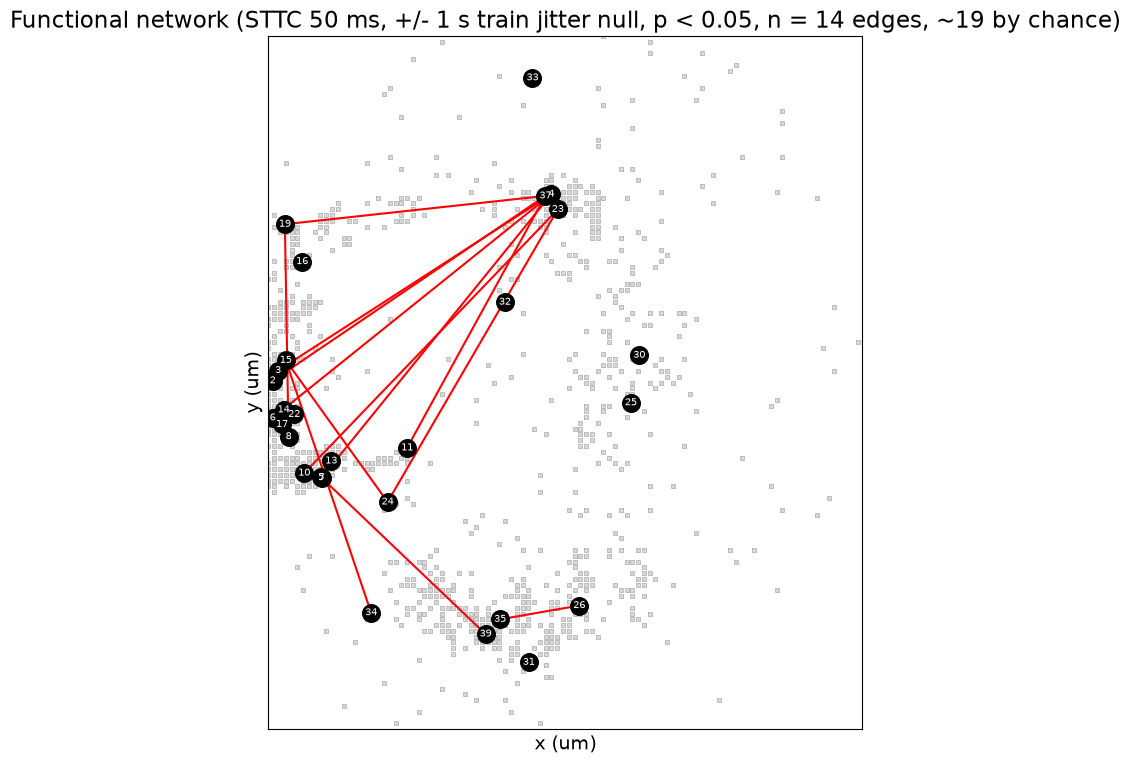

In [46]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(elec[:, 0], elec[:, 1], s=6, marker="s", facecolor="0.85", edgecolor="0.6", linewidth=0.4)
nx.draw_networkx(G, pos, ax=ax, node_size=160, node_color="k", font_color="w", font_size=7, edge_color=edge_colors, width=edge_widths)
ax.set(xlim=(0, 1800), ylim=(2100, 0), aspect="equal", xlabel="x (um)", ylabel="y (um)",
       title=f"Functional network (STTC {int(w * 1000)} ms, {null_name} null, p < 0.05, n = {G.number_of_edges()} edges, ~{0.05 * sig_95.size:.0f} by chance)")
plt.show()

### summary stats + motif "analysis"

In [47]:
deg = dict(G.degree)
triangles = sum(nx.triangles(G).values()) // 3
open_triads = sum(d * (d - 1) // 2 for d in deg.values()) - 3 * triangles
comps = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
stats = [("nodes", G.number_of_nodes()),
         ("edges (p < 0.05, uncorrected)", G.number_of_edges()),
         ("edges, BH-confirmed", n_conf),
         ("density", f"{nx.density(G):.4f}"),
         ("mean degree", f"{np.mean(list(deg.values())):.2f}"),
         ("max degree", max(deg.values())),
         ("isolated nodes", sum(d == 0 for d in deg.values())),
         ("connected pairs or larger", sum(c >= 2 for c in comps)),
         ("largest component", comps[0]),
         ("clustering coefficient", f"{nx.average_clustering(G):.3f}"),
         ("3-node motifs, triangles", triangles),
         ("3-node motifs, open triads", open_triads)]
pd.DataFrame(stats, columns=["metric", "value"]).set_index("metric")

,value
metric,
nodes,28
"edges (p < 0.05, uncorrected)",14
"edges, BH-confirmed",0
density,0.0370
mean degree,1.00
max degree,3
isolated nodes,11
connected pairs or larger,3
largest component,10
